# North Korea in South Korean National Assembly (1)

This notebook answers two questions:
- Which lawmaker proposed the largest number of bills on North Korea?
- Which political party proposed the largest number of bills on North Korea?

#### Summary
- This notebook uses two open-source APIs released by the National Assembly (https://open.assembly.go.kr/portal/openapi/main.do)
- Data from the 20th Congressional Session (May 2016 ~ May 2020) will be analyzed.
- To get and parse data, this notebook uses BeautifulSoup4. 
- For data analysis, this notebook uses Pandas Dataframe.

In [227]:
# Import modules.
import requests
import itertools
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib.pyplot import figure
import xml.etree.ElementTree as et 
import pandas as pd
from bs4 import BeautifulSoup

# Set font location for Korean letters.
font_location = "/Library/Fonts/NanumGothic.ttf"
font_name = fm.FontProperties(fname = font_location).get_name()

### 1. Fetching the Data

How can we determine whether a bill is related to North Korea or not? For the purpose of this analysis, I selected five keywords: "North Korea", "Inter-Korean", "to North Korea", "Korean Peninsula", "POW", and "abductees". These keywords will become a filter when I'm fetching the data from the National Assembly APIs.

For analysis, this notebook needs two datasets:
- List of bills related to North Korea
- List of lawmakers elected for the 20th Congressional Session, and their profile info.

In [241]:
# Set keywords related to North Korea.
keywords = ['북한', '남북', '한반도', '국군포로', '납북', '대북']

In [242]:
# Set the api token and url.
api_token = 'API-TOKEN'
api_url = 'https://open.assembly.go.kr/portal/openapi/nzmimeepazxkubdpn?'

# Set the congressional session I am going to look at. In this case, it's the 20th session.
session = 20

# Create an empty list to which I will add the entries of bills on North Korea.
bill_group = []

# Get bills that include any of the keywords. 
for n in range(len(keywords)):
    bill_queryParams = {'KEY': api_token,
                   'pIndex' : 1,
                   'pSize' : 1000,
                   'AGE' : session,
                   'BILL_NAME' : keywords[n]}
    bill_req = requests.get(api_url, bill_queryParams)
    bill_html = bill_req.text
    bill_soup = BeautifulSoup(bill_html, 'xml')
    bill_rows = bill_soup.find_all('row')
    bill_group.append(bill_rows)

# Flatten lists inside the list.
flatten = itertools.chain.from_iterable
flatten_group = list(flatten(bill_group))

# Remove duplicates from the list.
final_group = list(dict.fromkeys(flatten_group))

In [243]:
# Look at the format of each entry in the list just created.
print(final_group[0])

<row>
<BILL_ID>PRC_A2G0X0S2B1J1V1G0I5Y7K5L6T4L2T5</BILL_ID>
<BILL_NO>2024599</BILL_NO>
<BILL_NAME>북한이탈주민의 보호 및 정착지원에 관한 법률 일부개정법률안</BILL_NAME>
<COMMITTEE>외교통일위원회</COMMITTEE>
<PROPOSE_DT>2020-02-11</PROPOSE_DT>
<PROC_RESULT>임기만료폐기</PROC_RESULT>
<AGE>20</AGE>
<DETAIL_LINK>http://likms.assembly.go.kr/bill/billDetail.do?billId=PRC_A2G0X0S2B1J1V1G0I5Y7K5L6T4L2T5&amp;ageFrom=20&amp;ageTo=20</DETAIL_LINK>
<PROPOSER>홍일표의원 등 11인</PROPOSER>
<MEMBER_LIST>http://likms.assembly.go.kr/bill/coactorListPopup.do?billId=PRC_A2G0X0S2B1J1V1G0I5Y7K5L6T4L2T5</MEMBER_LIST>
<RST_PROPOSER>홍일표</RST_PROPOSER>
<PUBL_PROPOSER>강효상,권성동,김성찬,김세연,김재경,송희경,여상규,유민봉,이주영,정양석</PUBL_PROPOSER>
<COMMITTEE_ID>9700409</COMMITTEE_ID>
</row>


In [244]:
# Create an empty dataframe. The new dataframe will only include information of our interest.
column_names = ["BILL_ID", "BILL_NAME", "PROC_RESULT", "AGE", "RST_PROPOSER", "PUBL_PROPOSER"]
bill_df = pd.DataFrame(columns = column_names)

for n in range(0, len(final_group)):
    bill_df = bill_df.append({'BILL_ID': final_group[n].find('BILL_ID').get_text(),
                   'BILL_NAME': final_group[n].find('BILL_NAME').get_text(),
                   'PROC_RESULT': final_group[n].find('PROC_RESULT').get_text(),
                   'AGE': final_group[n].find('AGE').get_text(),
                   'RST_PROPOSER': final_group[n].find('RST_PROPOSER').get_text(),
                   'PUBL_PROPOSER': final_group[n].find('PUBL_PROPOSER').get_text()}, 
                   ignore_index = True)

In [245]:
# Check whether the new dataframe includes all necessary information.
bill_df.head(3)

,BILL_ID,BILL_NAME,PROC_RESULT,AGE,RST_PROPOSER,PUBL_PROPOSER
0,PRC_A2G0X0S2B1J1V1G0I5Y7K5L6T4L2T5,북한이탈주민의 보호 및 정착지원에 관한 법률 일부개정법률안,임기만료폐기,20,홍일표,"강효상,권성동,김성찬,김세연,김재경,송희경,여상규,유민봉,이주영,정양석"
1,PRC_N2T0F0R2T1Y1A1I0B4B7W5T4K0D6X9,북한인권법 일부개정법률안,임기만료폐기,20,홍일표,"강효상,권성동,김성찬,김세연,김재경,송희경,여상규,유민봉,이주영,정양석"
2,PRC_E1S9H1V1F2O9E1T6F4A5E3V4V9H4Z2,북한인권법 일부개정법률안,임기만료폐기,20,정병국,"강석호,김무성,김세연,김수민,김학용,성일종,신상진,원유철,유기준,유승민,유의동,이언..."


In [246]:
# Set the api url.
lm_api_url = "https://open.assembly.go.kr/portal/openapi/npffdutiapkzbfyvr"

# Create an empty list to which I will add the entries of bills on North Korea.
lm_group = []

# Get the data of lawmakers active during the 20th Congressional session.
lm_queryParams = {'KEY': api_token,
               'pIndex' : 1,
               'pSize' : 350,
               'UNIT_CD': 100020}

lm_req = requests.get(lm_api_url, lm_queryParams)
lm_html = lm_req.text
lm_soup = BeautifulSoup(lm_html, 'xml')
lm_rows = lm_soup.find_all('row')
lm_group.append(lm_rows)

# Flatten lists inside the list.
flatten = itertools.chain.from_iterable
flatten_group = list(flatten(lm_group))

# Remove duplicates from the list.
lm_final_group = list(dict.fromkeys(flatten_group))

In [247]:
# Create an empty dataframe.
column_names = ["MONA_CD", "HG_NM", "ENG_NM", "POLY_NM"]
lm_df = pd.DataFrame(columns = column_names)

for n in range(0, len(lm_final_group)):
    lm_df = lm_df.append({"MONA_CD": lm_final_group[n].find("MONA_CD").get_text(),
                   "HG_NM": lm_final_group[n].find("HG_NM").get_text(),
                   "ENG_NM": lm_final_group[n].find("ENG_NM").get_text(),
                   "POLY_NM": lm_final_group[n].find("POLY_NM").get_text()},
                   ignore_index = True)

In [248]:
# Check whether the new dataframe includes all necessary information.
lm_df.head(3)

,MONA_CD,HG_NM,ENG_NM,POLY_NM
0,XQ98168F,강길부,KANG GHILBOO,무소속
1,60490713,강병원,KANG BYUNGWON,더불어민주당
2,IH436704,강석진,KANG SEOGJIN,새누리당


### 2. Preparing Data for Analysis

The first dataframe does not have lawmakers' profile info, while the second dataframe does not have any information about bills on North Korea. Those two dataframes should be joined together for analysis.

In [249]:
# Merge by the name of lawmakers/proposer of bills.
p_party = pd.merge(bill_df, lm_df, left_on = 'RST_PROPOSER', right_on = 'HG_NM')

In [250]:
# Check the format of the new dataframe.
p_party.head(3)

,BILL_ID,BILL_NAME,PROC_RESULT,AGE,RST_PROPOSER,PUBL_PROPOSER,MONA_CD,HG_NM,ENG_NM,POLY_NM
0,PRC_A2G0X0S2B1J1V1G0I5Y7K5L6T4L2T5,북한이탈주민의 보호 및 정착지원에 관한 법률 일부개정법률안,임기만료폐기,20,홍일표,"강효상,권성동,김성찬,김세연,김재경,송희경,여상규,유민봉,이주영,정양석",06L2365K,홍일표,HONG ILPYO,새누리당
1,PRC_N2T0F0R2T1Y1A1I0B4B7W5T4K0D6X9,북한인권법 일부개정법률안,임기만료폐기,20,홍일표,"강효상,권성동,김성찬,김세연,김재경,송희경,여상규,유민봉,이주영,정양석",06L2365K,홍일표,HONG ILPYO,새누리당
2,PRC_E1S9H1V1F2O9E1T6F4A5E3V4V9H4Z2,북한인권법 일부개정법률안,임기만료폐기,20,정병국,"강석호,김무성,김세연,김수민,김학용,성일종,신상진,원유철,유기준,유승민,유의동,이언...",P303213F,정병국,CHOUNG BYOUNGGUG,새누리당


### 3. Analysis

Now, we have all the data ready. Using the completed dataframe, this notebook answers two questions, who and which party proposed the largest number of bills on North Korea during the 20th Congressional session.

In [251]:
# Use pandas groupby function to find out the lawmaker.
proposers = p_party.groupby(by = "ENG_NM").agg("count").sort_values(by = ['BILL_ID'], ascending = False).reset_index()
proposers.head(10)

,ENG_NM,BILL_ID,BILL_NAME,PROC_RESULT,AGE,RST_PROPOSER,PUBL_PROPOSER,MONA_CD,HG_NM,POLY_NM
0,LEE INYOUNG,9,9,9,9,9,9,9,9,9
1,SONG GABSEOK,7,7,7,7,7,7,7,7,7
2,HONG IHKPYO,6,6,6,6,6,6,6,6,6
3,KIM JAEKYUNG,5,5,5,5,5,5,5,5,5
4,SUL HOON,5,5,5,5,5,5,5,5,5
5,LEE SEOKHYUN,5,5,5,5,5,5,5,5,5
6,CHOI GYUNGHWAN,5,5,5,5,5,5,5,5,5
7,CHOI KYUNGHWAN,5,5,5,5,5,5,5,5,5
8,CHUN JUNGBAE,5,5,5,5,5,5,5,5,5
9,LEE SOOHYUCK,4,4,4,4,4,4,4,4,4


What we can learn from this list:
- Lee In-young, the current Unifiction minister of South Korea, is the lawmaker who proposed the largest number of bills in the 20th Congressional session. 
- All three top lawmakers on the list, including Lee, are the members of South Korea's liberal Minjoo Party.

But Does this indicate that the liberal Minjoo Party tend to propose more laws on North Korea? To answer this question, we need to use groupby function once more to see the result.

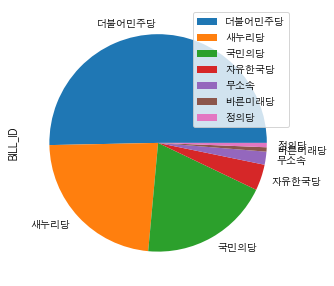

In [252]:
# Use pandas groupby function to find out which party proposes the largest number of bills.
parties = p_party.groupby(by = "POLY_NM").agg("count").sort_values(by = ['BILL_ID'], ascending = False)
plot = parties.plot.pie(y='BILL_ID', figsize=(5, 5))

- The pie chart shows that the liberal Minjoo Party (더불어민주당) was the party with the most prolific record of proposing bills related to North Korea.
- Next in the list are conservative 새누리당 (current-day People's Power Party) and 국민의당.

### 4. Conclusion
- Lee In-young, the current South Korean Unification minister, was the lawmaker who proposed the largest number of bills on North Korea during the 20th Congressional Session.
- Lawmakers who made into the top 3 in the list were all members of the liberal Minjoo Party.
- In the 20th Congressional session, almost 50% of the bills on North Korea were proposed by lawmakers from the liberal Minjoo Party. 

### 5. Next Analysis
- How many bills on North Korea actually became law?
- How many bills on North Korea were passed in the committee where the bill was originally proposed, and how many among them were actually put on the vote at the genreal session?